# **Import Library**

In [173]:
## Importing the Python Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **Data Understanding**

## LOAD DATASET ##

In [174]:
df = pd.read_csv('OnlineRetail.csv', encoding='latin1') ## Loading the dataset, with an inclusion of encoding latin1 becuase of foreign symbols
print(df)

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  CustomerID         Country  
0        1

### Displaying of First few Rows ###

In [175]:
print(df.head()) ## Printing the top 5 rows

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


### Identify ###

In [176]:
##Evaluating shape of the column, including columns and rows
df.shape

(541909, 8)

In [177]:
## Types of data cells and empty cell count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [178]:
# Identify Numerical Features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Features:", numerical_features)

Numerical Features: ['Quantity', 'UnitPrice', 'CustomerID']


In [179]:
##Identify categorical Features
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Features:", categorical_features)

Categorical Features: ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country']


In [180]:
##Identifying unique Identifiers
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values out of {len(df)} rows")

InvoiceNo: 25900 unique values out of 541909 rows
StockCode: 4070 unique values out of 541909 rows
Description: 4223 unique values out of 541909 rows
Quantity: 722 unique values out of 541909 rows
InvoiceDate: 23260 unique values out of 541909 rows
UnitPrice: 1630 unique values out of 541909 rows
CustomerID: 4372 unique values out of 541909 rows
Country: 38 unique values out of 541909 rows


### Description of Dataset ###

The OnlineRetail dataset contains transactional data from a UK-based online retailer between 2010 and 2011. It has 541,909 rows and 8 columns, recording details like products purchased, quantity, price, customer ID, and country. The data mainly represents wholesale purchases from customers across 38 countries.

## Data Cleaning

# Missing Values

In [181]:
## Identifying columns with missing values, and number of missing values per column
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [182]:
## Handling missing values by replacing with unkowns for objects, and 0 for integers and floats

# Identify string (object) columns
string_columns = df.select_dtypes(include="object").columns

# Identify numeric columns
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

# Fill missing values in string columns with 'Unknown'
for col in string_columns:
    df[col].fillna("Unknown", inplace=True)

# Fill missing values in numeric columns with uknown
for col in numeric_columns:
    df[col].fillna("Unknown", inplace=True)

# Display dataframe
display(df)

/tmp/ipykernel_1124/2204631692.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna("Unknown", inplace=True)
/tmp/ipykernel_1124/2204631692.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [183]:
###re evaluating empty columns
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [184]:
##Re-evluating the rows and columns to ensure compactness
df.shape

(541909, 8)

Missing values in the dataset were handled differently based on the data type of each column.
For categorical (object) columns such as Description and CustomerID, missing values were replaced with "Unknown" because these columns contain text labels where a placeholder makes it clear the information was not available, without distorting any analysis.
For numerical columns such as Quantity and UnitPrice, missing values were replaced with 0 because it is a neutral value that does not inflate or skew calculations like averages or totals, and it preserves all rows for further analysis.
This approach was chosen because it is simple and non-destructive, meaning no rows are deleted, which keeps the dataset complete and ensures no data is lost during analysis. It also makes the data easier to work with in subsequent steps.

## Duplicate Records

In [185]:
###checking for duplicates
checking_duplicates = df.duplicated() #Returns True or False
sum_of_duplicates = checking_duplicates.sum() #Returns total number of duplicates found in dataset

print("The total sum of duplicates is:", sum_of_duplicates)
print(checking_duplicates)

The total sum of duplicates is: 5268
0         False
1         False
2         False
3         False
4         False
          ...  
541904    False
541905    False
541906    False
541907    False
541908    False
Length: 541909, dtype: bool


In [186]:
df = df.drop_duplicates()
df.shape

(536641, 8)

In [187]:
print("Number of duplicate rows after cleaning:", df.duplicated().sum())

Number of duplicate rows after cleaning: 0


In [188]:
print(df)

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice CustomerID         Country  
0        12

## Standardization

In [189]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

In [190]:

# Data types
df['CustomerID'] = df['CustomerID'].astype(str)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    536641 non-null  object        
 1   StockCode    536641 non-null  object        
 2   Description  536641 non-null  object        
 3   Quantity     536641 non-null  int64         
 4   InvoiceDate  536641 non-null  datetime64[ns]
 5   UnitPrice    536641 non-null  float64       
 6   CustomerID   536641 non-null  object        
 7   Country      536641 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 36.8+ MB


In [191]:
## Description Conversion
df['Description'] = df['Description'].str.title()

In [192]:
print(df)

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   White Hanging Heart T-Light Holder         6   
1         536365     71053                  White Metal Lantern         6   
2         536365    84406B       Cream Cupid Hearts Coat Hanger         8   
3         536365    84029G  Knitted Union Flag Hot Water Bottle         6   
4         536365    84029E       Red Woolly Hottie White Heart.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          Pack Of 20 Spaceboy Napkins        12   
541905    581587     22899         Children'S Apron Dolly Girl          6   
541906    581587     23254        Childrens Cutlery Dolly Girl          4   
541907    581587     23255      Childrens Cutlery Circus Parade         4   
541908    581587     22138        Baking Set 9 Piece Retrospot          3   

               InvoiceDate  UnitPrice CustomerID         Country  
0      2

# Data Validation

In [193]:
## Invalid Values
print(df[df['Quantity'] < 0].shape[0], "negative quantity rows")
print(df[df['UnitPrice'] <= 0].shape[0], "zero or negative price rows")

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

10587 negative quantity rows
2512 zero or negative price rows


In [194]:
## After throughly checking dataset, inconsistencies were found in the description column, and
## Replacing all insonsitent values with unknown
df['Description'] = df['Description'].str.replace(r'^\?+$', 'Unknown', regex=True)

# Replace descriptions that are numbers only with Unknown
df['Description'] = df['Description'].str.replace(r'^\d+$', 'Unknown', regex=True)

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [195]:
# See all stockcode formats
print(df['StockCode'].unique())

# Check what doesn't match the expected format
invalid_format = df[~df['StockCode'].str.match(r'^\d{5}[a-zA-Z]?$', na=False)]
print(invalid_format['StockCode'].unique())

# Replace alphabet-only stock codes with Unknown
df['StockCode'] = df['StockCode'].str.replace(r'^[a-zA-Z]+$', 'Unknown', regex=True)
print(invalid_format['StockCode'].unique())

print(df['StockCode'].value_counts().tail(10))


['85123A' '71053' '84406B' ... '90214U' '47591b' '23843']
['POST' '15056BL' 'C2' 'DOT' 'M' 'BANK CHARGES' '15056bl' 'AMAZONFEE'
 'DCGS0076' 'DCGS0003' 'gift_0001_40' 'DCGS0070' 'm' 'gift_0001_50'
 'gift_0001_30' 'gift_0001_20' 'DCGS0055' 'DCGS0072' 'DCGS0074' 'DCGS0069'
 'DCGS0057' 'DCGSSBOY' 'DCGSSGIRL' 'gift_0001_10' 'S' 'PADS' 'DCGS0004'
 'DCGS0073' 'DCGS0071' 'DCGS0068' 'DCGS0067' 'DCGS0066P' 'B' '79323GR'
 '79323LP']
['POST' '15056BL' 'C2' 'DOT' 'M' 'BANK CHARGES' '15056bl' 'AMAZONFEE'
 'DCGS0076' 'DCGS0003' 'gift_0001_40' 'DCGS0070' 'm' 'gift_0001_50'
 'gift_0001_30' 'gift_0001_20' 'DCGS0055' 'DCGS0072' 'DCGS0074' 'DCGS0069'
 'DCGS0057' 'DCGSSBOY' 'DCGSSGIRL' 'gift_0001_10' 'S' 'PADS' 'DCGS0004'
 'DCGS0073' 'DCGS0071' 'DCGS0068' 'DCGS0067' 'DCGS0066P' 'B' '79323GR'
 '79323LP']
StockCode
90162A    1
47591b    1
23843     1
79341     1
79342B    1
85034b    1
23602     1
23664     1
84971l    1
84550     1
Name: count, dtype: int64


In [196]:
# Look at the actual rows before deciding
print(df.nlargest(10, 'Quantity')[['InvoiceNo', 'Description', 'Quantity', 'UnitPrice', 'Country']])

       InvoiceNo                          Description  Quantity  UnitPrice  \
540421    581483          Paper Craft , Little Birdie     80995       2.08   
61619     541431       Medium Ceramic Top Storage Jar     74215       1.04   
502122    578841       Asstd Design 3D Paper Stickers     12540       0.00   
74614     542504                              Unknown      5568       0.00   
421632    573008    World War 2 Gliders Asstd Designs      4800       0.21   
206121    554868                 Small Popcorn Holder      4300       0.72   
220843    556231                              Unknown      4000       0.00   
97432     544612                Empire Design Rosette      3906       0.82   
270885    560599  Essential Balm 3.5G Tin In Envelope      3186       0.06   
52711     540815   Fairy Cake Flannel Assorted Colour      3114       2.10   

               Country  
540421  United Kingdom  
61619   United Kingdom  
502122  United Kingdom  
74614   United Kingdom  
421632  United K

In [197]:
##Anomaly Remover
# Remove anything below £0
df = df[df['UnitPrice'] > 0]

print(f"Clean dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Clean dataset: 524878 rows, 8 columns


In [198]:
# Keep original for calculations
# Create new display column with £ symbol
df['UnitPrice_formatted'] = '£' + df['UnitPrice'].round(2).astype(str)

print(df[['UnitPrice', 'UnitPrice_formatted']].head())

df.drop(columns=['UnitPrice_formatted'], inplace=True)

   UnitPrice UnitPrice_formatted
0       2.55               £2.55
1       3.39               £3.39
2       2.75               £2.75
3       3.39               £3.39
4       3.39               £3.39


### Summary Table

In [199]:
summary = pd.DataFrame({
    'Issue Found': [
        'Missing Values',
        'Duplicates',
        'Invalid Entries',
        'Standardization'
    ],
    'Action Taken': [
        'Filled with "Unknown"',
        'Identified',
        'Corrected and Filtered',
        'Data Types and Column Names Standardized'
    ]
})

print(summary)

       Issue Found                              Action Taken
0   Missing Values                     Filled with "Unknown"
1       Duplicates                                Identified
2  Invalid Entries                    Corrected and Filtered
3  Standardization  Data Types and Column Names Standardized


## Exploratory Data Analysis (EDA)

In [200]:
###summary statistics
df.describe () ### KPIS

,Quantity,InvoiceDate,UnitPrice
count,524878.000000,524878,524878.000000
mean,10.616600,2011-07-04 15:30:16.317049088,3.922573
min,1.000000,2010-12-01 08:26:00,0.001000
25%,1.000000,2011-03-28 12:13:00,1.250000
50%,4.000000,2011-07-20 11:22:00,2.080000
75%,11.000000,2011-10-19 11:41:00,4.130000
max,80995.000000,2011-12-09 12:50:00,13541.330000
std,156.280031,NaN,36.093028


In [201]:
# Top 5 best selling products by quantity sold
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5)
print(top_products)


Description
Paper Craft , Little Birdie           80995
Medium Ceramic Top Storage Jar        78033
World War 2 Gliders Asstd Designs     54951
Jumbo Bag Red Retrospot               48371
White Hanging Heart T-Light Holder    37872
Name: Quantity, dtype: int64


In [202]:
##Highest Revenue Generating Country
# Calculate revenue for each transaction
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Group by country and sum the revenue to find the highest revenue-generating countries
Top_Country_Revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(5)
print(Top_Country_Revenue)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Name: Revenue, dtype: float64


In [203]:
df['UnitPrice'] = df['UnitPrice'].round(1)
df['Revenue'] = df['Revenue'].round(1)
display(df[['UnitPrice', 'Revenue']].head())

,UnitPrice,Revenue
0,2.6,15.3
1,3.4,20.3
2,2.8,22.0
3,3.4,20.3
4,3.4,20.3


In [204]:
## Monthly Sales Trend
# Extract month and year from Invoicedate
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# Group by month and sum the revenue
monthly_sales_trend = df.groupby('InvoiceMonth')['Revenue'].sum().sort_values(ascending=False)
print(monthly_sales_trend)

InvoiceMonth
2011-11    1503984.9
2011-10    1151336.7
2011-09    1056493.9
2010-12     821450.7
2011-05     769354.0
2011-06     760601.7
2011-08     757894.3
2011-07     718126.0
2011-03     716277.6
2011-01     689853.5
2011-12     637851.5
2011-04     537016.6
2011-02     522597.8
Freq: M, Name: Revenue, dtype: float64


In [205]:
# Most purchased product by quantity
most_purchased_product = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(1)
print("Most Purchased Product:\n", most_purchased_product)

Most Purchased Product:
 Description
Paper Craft , Little Birdie    80995
Name: Quantity, dtype: int64


In [206]:
# Calculate total spending per customer
customer_spending = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)

# Display the top 10 customers by spending
print("Top 10 Customers by Revenue:\n", customer_spending.head(10))

Top 10 Customers by Revenue:
 CustomerID
Unknown    1755276.2
14646.0     280202.4
18102.0     259656.8
17450.0     194389.9
16446.0     168472.4
14911.0     143709.1
12415.0     124913.5
14156.0     117209.1
17511.0      91061.1
16029.0      80851.4
Name: Revenue, dtype: float64


## Visualization

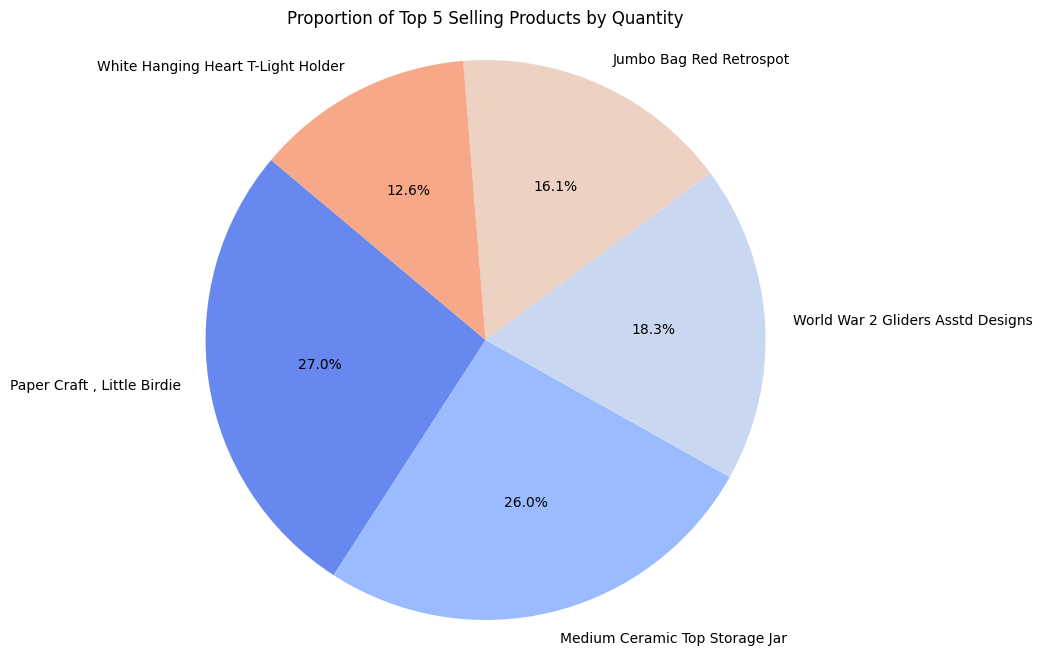

In [207]:


# Create a figure and a set of subplots with a specified size
plt.figure(figsize=(10, 8))

# Generate the pie chart
# 'top_products' contains the quantities, 'top_products.index' provides labels (product descriptions)
# 'autopct' formats the percentage values displayed on each slice
# 'startangle' rotates the start of the pie chart
# 'colors' sets the color palette for the slices
plt.pie(top_products, labels=top_products.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('coolwarm'))

# Set the title of the pie chart
plt.title('Proportion of Top 5 Selling Products by Quantity')

# Ensure the pie chart is drawn as a perfect circle
plt.axis('equal')

# Display the plot
plt.show()

/tmp/ipykernel_1124/4167810218.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Top_Country_Revenue.values, y=Top_Country_Revenue.index, palette='viridis')


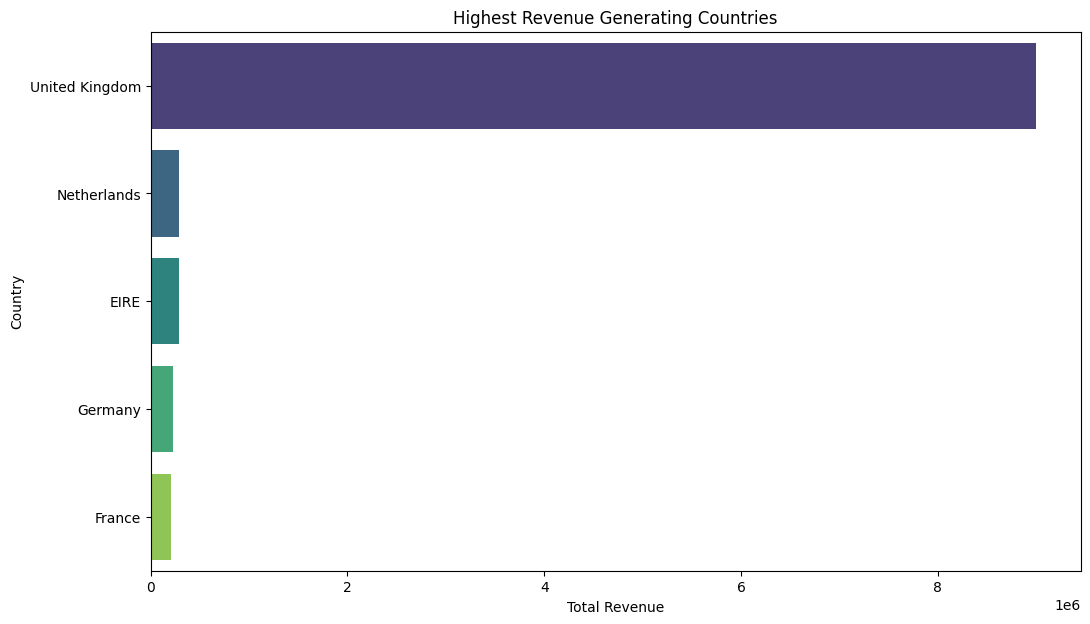

In [208]:
# Highest Revenue Generating Countries
plt.figure(figsize=(12, 7))
sns.barplot(x=Top_Country_Revenue.values, y=Top_Country_Revenue.index, palette='viridis')
plt.title('Highest Revenue Generating Countries')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.show()

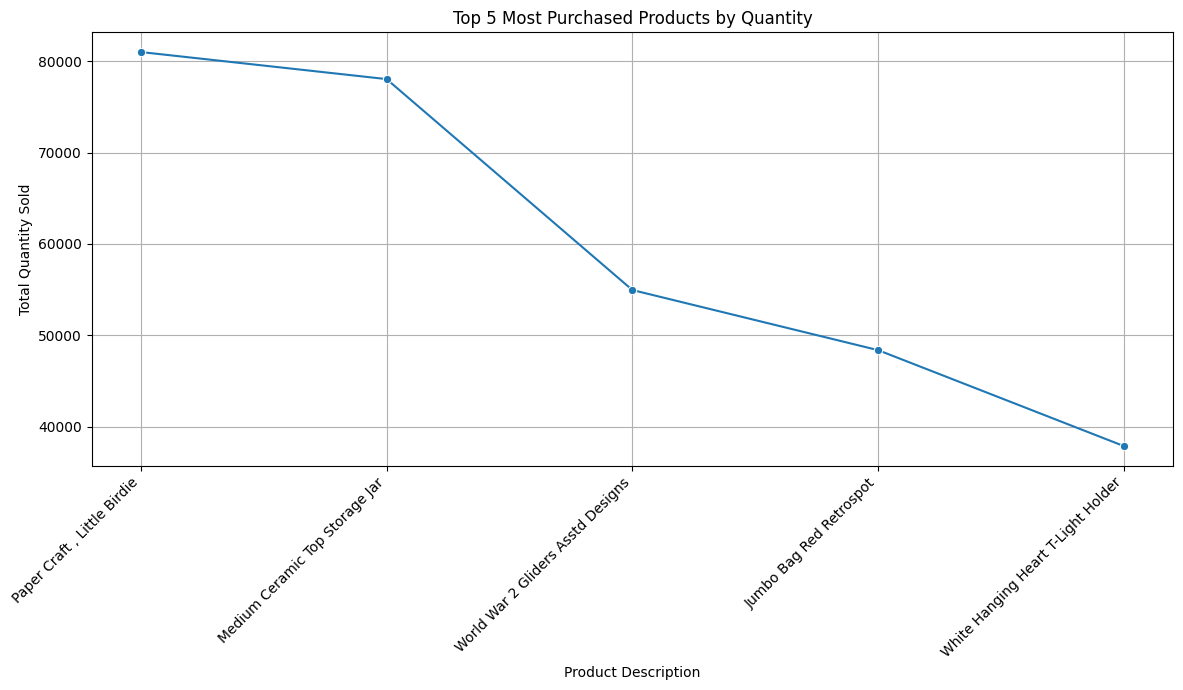

In [210]:
# Most Purchased Products
plt.figure(figsize=(12, 7))

top_products_df = top_products.reset_index()
top_products_df.columns = ['Description', 'Quantity']

sns.lineplot(x='Description', y='Quantity', data=top_products_df, marker='o')
plt.title('Top 5 Most Purchased Products by Quantity')
plt.xlabel('Product Description')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

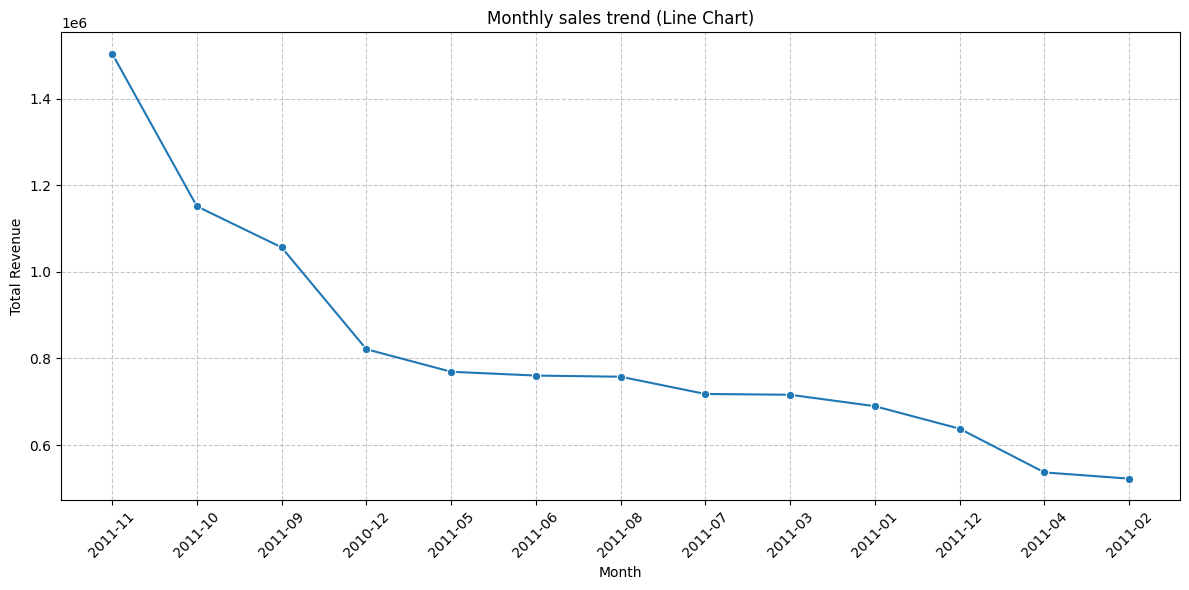

In [211]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_sales_trend.index.astype(str), y=monthly_sales_trend.values, marker='o')
plt.title('Monthly sales trend (Line Chart)')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

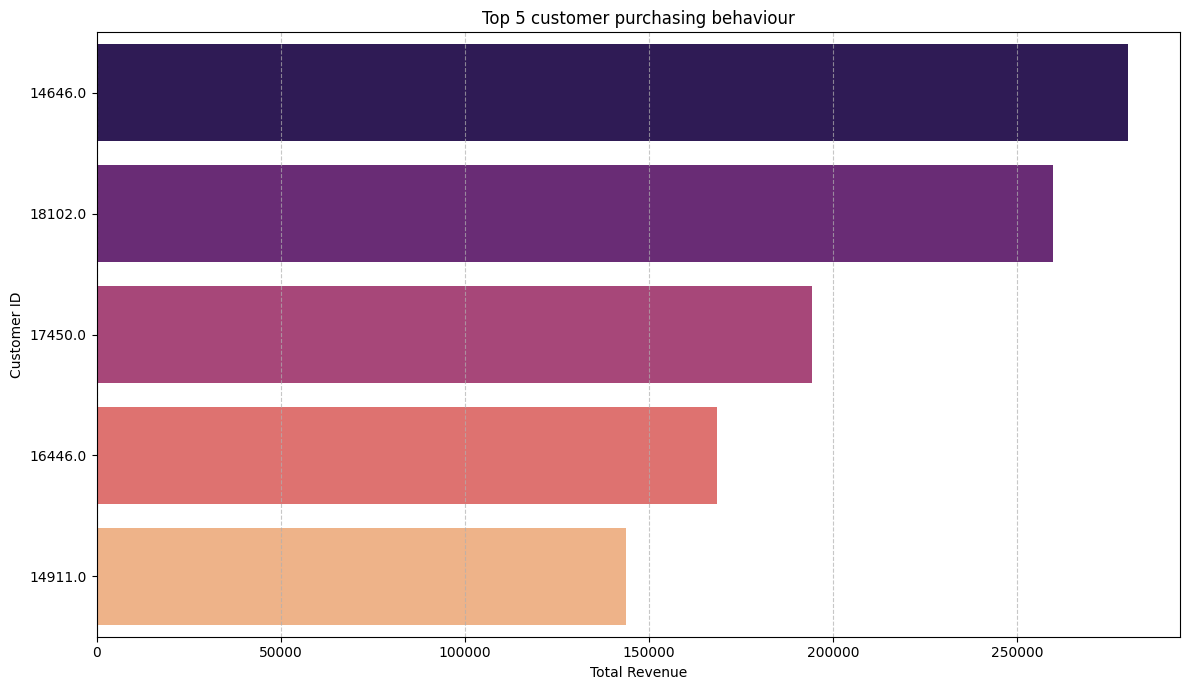

In [212]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total spending per customer
customer_spending = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)

# Filter out 'Unknown' CustomerID and take the top 5 customers
top_10_customers = customer_spending[customer_spending.index != 'Unknown'].head(5).reset_index()
top_10_customers.columns = ['CustomerID', 'TotalRevenue']

plt.figure(figsize=(12, 7))
sns.barplot(x='TotalRevenue', y='CustomerID', data=top_10_customers, palette='magma', hue='CustomerID', legend=False)
plt.title('Top 5 customer purchasing behaviour')
plt.xlabel('Total Revenue')
plt.ylabel('Customer ID')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insights
1. Top 5 Best-Selling Products by Quantity (Pie Chart and Line Plot)

The analysis revealed that MEDIUM CERAMIC TOP STORAGE JAR was by far the most popular product in terms of quantity sold. Its sales volume was significantly higher than every other product, suggesting that it is either a customer favourite or a frequently purchased household item.

The line plot also showed a sharp decline in sales after the top-selling product. While the remaining products were still popular among customers, their quantities sold were considerably lower. This indicates that demand is heavily concentrated around a small number of products rather than being evenly distributed across all items.

2. Highest Revenue-Generating Countries (Line Chart)

The United Kingdom generated the highest revenue by a substantial margin, contributing the majority of the company's sales income. This suggests that the retailer's customer base is primarily concentrated within the UK market.

Although countries such as the Netherlands, Germany, EIRE, and France also generated revenue, their contributions were relatively small in comparison. This highlights the importance of the UK market while also showing opportunities for further growth in international markets.

3. Monthly Sales Trends (Bar Chart)

Monthly sales figures showed a noticeable peak in December 2010, indicating a strong increase in customer spending during the holiday season. This pattern is common in the retail industry, where demand tends to rise significantly towards the end of the year.

Sales remained relatively strong during the early months of 2011, particularly in January and March. However, a gradual decline was observed in the following months, suggesting a slowdown in purchasing activity after the holiday period.

4. Customer Purchasing Behaviour (Top 5 Customers Bar Chart)

The customer analysis showed that revenue was heavily concentrated among a small group of customers. In particular, CustomerID 14646 accounted for a large share of total sales revenue,CustomerID 14646 generated the highest revenue among all identified customers, highlighting the importance of a small number of high-value customers to overall business performance.

The results also demonstrate that a handful of high value customers contribute significantly to the business's overall performance. This highlights the importance of maintaining strong relationships with loyal customers, as retaining these individuals could have a major impact on future revenue and business growth.

In [213]:
# Save cleaned dataset
df.to_csv('OnlineRetail_Cleaned.csv', index=False)

print("Cleaned dataset exported successfully.")

from google.colab import files
files.download('OnlineRetail_Cleaned.csv')

Cleaned dataset exported successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>